# Actividad - Proyecto práctico


> La actividad se desarrollará en grupos pre-definidos de 4 alumnos. Se debe indicar los nombres en orden alfabético (de apellidos). Recordad que esta actividad se corresponde con un 30% de la nota final de la asignatura. Se debe entregar entregar el trabajo en la presente notebook.
*   Alumno 1: Emma Oitaven Carracedo
*   Alumno 2: Ramiro Rivas Fernández
*   Alumno 3: Víctor Rodríguez Rodríguez
*   Alumno 4: Nicolás Zamorano Ramírez






---
## **Preliminares** - Configuración del entorno

> Estas instrucciones documentan el proceso de configuración del entorno de trabajo en local con Windows + Miniconda + VS Code. El proyecto está pensado originalmente para Colab, pero la renderización de gym requiere ejecución en local.

### Pasos seguidos en local (Windows + Miniconda + VS Code)

Se ha creado un environment de conda con Python 3.8 e instalado las librerías en un orden controlado para evitar conflictos de dependencias (TensorFlow y Keras son especialmente sensibles a esto).

```bash
# 1) Crear environment con Python 3.8 (requerido por gym 0.17.3)
conda create --name miar_rl python=3.8 -y
conda activate miar_rl

# 2) Herramientas base
python -m pip install --upgrade pip setuptools wheel

# 3) TensorFlow primero, fijado (evita que keras-rl2 arrastre una versión incompatible)
pip install tensorflow==2.5.3

# 4) Dependencias compatibles
pip install numpy==1.19.5 h5py==3.1.0 Pillow==9.5.0 pyglet==1.5.0
pip install gym==0.17.3

# 5) keras-rl2 sin dependencias (para que no pise TensorFlow)
pip install --no-deps keras-rl2==1.0.5

# 6) Kernel para VS Code
pip install ipykernel
python -m ipykernel install --user --name miar_rl --display-name "Python (miar_rl)"
```

Con esto, basta seleccionar el kernel **"Python (miar_rl)"** desde VS Code al abrir el notebook.

**Nota sobre el entorno Acrobot-v1 del Grupo 1**: al ser un entorno de *Classic Control* (no Atari), no requiere instalar `atari-py` ni gestionar ROMs.

---

In [ ]:
# Importación de todas las librerías usadas durante el proyecto

# --- Librería estándar ---
import os
import time
import json

# --- Cálculo numérico y visualización ---
import numpy as np
import gym
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

# --- keras-rl2 (algoritmo DQN) ---
from rl.agents.dqn import DQNAgent
from rl.policy import LinearAnnealedPolicy, EpsGreedyQPolicy
from rl.memory import SequentialMemory
from rl.core import Processor
from rl.callbacks import FileLogger, ModelIntervalCheckpoint

# --- Generación de GIFs y visualización de resultados ---
import imageio
from PIL import Image, ImageDraw, ImageFont

# --- Utilidades ---
from importlib.metadata import version

In [ ]:
# Verificación del entorno: versiones esperadas

print("Python    :", sys.version.split()[0])
print("TensorFlow:", version("tensorflow"))
print("gym       :", version("gym"))
print("keras-rl2 :", version("keras-rl2"))
print("numpy     :", version("numpy"))

Python    : 3.8.20
TensorFlow: 2.5.3
gym       : 0.17.3
keras-rl2 : 1.0.5
numpy     : 1.19.5


---
## **PARTE 1**. Enunciado

Consideraciones a tener en cuenta:

- El entorno sobre el que trabajaremos será el indicado en el listado correspondien de cada grupo y el algoritmo que usaremos será _DQN_.

- Para nuestro ejercicio, el requisito mínimo será alcanzado cuando el agente consiga una **media de recompensa por encima de los puntos indicados en el listado por grupos en modo test**. Por ello, esta media de la recompensa se calculará a partir del código de test en la última celda del notebook.

Este proyecto práctico consta de tres partes:

1.   Implementar la red neuronal que se usará en la solución
2.   Implementar las distintas piezas de la solución DQN y probar al menos 3 propuestas diferentes de mejora.
3.   Justificar la respuesta en relación a los resultados obtenidos e incluir al menos 3 gráficas relevantes comparando las 3 propuestas.

**Rúbrica**: Se valorará la originalidad en la solución aportada, así como la capacidad de discutir los resultados de forma detallada. El requisito mínimo servirá para aprobar la actividad, bajo premisa de que la discusión del resultado sera apropiada.

IMPORTANTE:

* Si no se consigue una puntuación óptima, responder sobre la mejor puntuación obtenida.
* Para entrenamientos largos, recordad que podéis usar checkpoints de vuestros modelos para retomar los entrenamientos. En este caso, recordad cambiar los parámetros adecuadamente (sobre todo los relacionados con el proceso de exploración).
* Se deberá entregar unicamente el notebook y los pesos del mejor modelo en un fichero .zip, de forma organizada.
* Cada alumno deberá de subir la solución de forma individual.

---
## **PARTE 2**. Desarrollo y preguntas

#### Importar librerías

In [ ]:
# Comprobamos la versión de TensorFlow y si detecta GPU

print("TF version:", tf.__version__)
print("Keras (tf.keras) version:", tf.keras.__version__)
print("Physical GPUs:", tf.config.list_physical_devices('GPU'))
print("Logical GPUs:", tf.config.list_logical_devices('GPU'))

c:\Users\victo\miniconda3\envs\miar_rl\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\Users\victo\miniconda3\envs\miar_rl\lib\site-packages\numpy\.libs\libopenblas.WCDJNK7YVMPZQ2ME2ZZHJJRJ3JIKNDB7.gfortran-win_amd64.dll
c:\Users\victo\miniconda3\envs\miar_rl\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"
c:\Users\victo\miniconda3\envs\miar_rl\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


TF version: 2.5.3
Keras (tf.keras) version: 2.5.0
Physical GPUs: []
Logical GPUs: []


#### Configuración base

In [ ]:
# Configuración base para Acrobot-v1
env_name = 'Acrobot-v1'
env = gym.make(env_name)

# Semilla
np.random.seed(123)
env.seed(123)

# Parámetros del entorno
INPUT_SHAPE = env.observation_space.shape
WINDOW_LENGTH = 1 # 1 único estado por observación
nb_actions = env.action_space.n # acciones disponibles

print(f"Entorno: {env_name}")
print(f"Espacio de observación: {env.observation_space}")
print(f"Espacio de acciones: {env.action_space} - {nb_actions} acciones")
print(f"INPUT_SHAPE: {INPUT_SHAPE}, WINDOW_LENGTH: {WINDOW_LENGTH}")

Entorno: Acrobot-v1
Espacio de observación: Box(-28.274333953857422, 28.274333953857422, (6,), float32)
Espacio de acciones: Discrete(3) -> 3 acciones
INPUT_SHAPE: (6,), WINDOW_LENGTH: 1


In [ ]:
class AcrobotProcessor(Processor):
    """Procesador de las observaciones de Acrobot-v1."""
    
    # Valores máximos de las velocidades angulares
    THETA1_DOT_MAX = 4 * np.pi
    THETA2_DOT_MAX = 9 * np.pi

    def process_observation(self, observation):
        assert observation.shape == (6,)
        obs = np.asarray(observation, dtype=np.float32).copy()

        # Normalizar las velocidades angulares
        obs[4] /= self.THETA1_DOT_MAX
        obs[5] /= self.THETA2_DOT_MAX

        return obs

    def process_state_batch(self, batch):
        # Aseguramos dtype float32 para el modelo Keras
        return batch.astype('float32')

### Búsqueda manual de hiperparámetros sobre el baseline

Antes de hacer una comparativa entre las diferentes variantes de DQN, se ha realizado una búsqueda manual de hiperparámetros sobre la configuración **DQN baseline**. Se han empleado 5 combinaciones de hiperparámetros con el objetivo de acercar su recompensa media al umbral de **-100** (resuelto).

La búsqueda se centra en evaluar distintas combinaciones de cuatro parámetros que tienen un impacto importante en el entrenamiento:

- **Tamaño de red** (`hidden_size`): 64 vs 128 neuronas por capa oculta.
- **Learning rate** del optimizador Adam.
- **Batch size** para la actualización por replay.
- **Número de pasos de entrenamiento**.

En cada trial se cambia solo uno de estos parámetros respecto a la configuración base, de forma que se pueda observar el efecto de cada modificación. La comparación se realiza por pares: `B0 vs B1` mide el efecto puro de aumentar la red; `B0 vs B2` el efecto puro de aumentar los pasos, etc.

Todos los experimentos emplean la misma semilla que en el resto del proyecto (`SEED=123`) para mantener unas condiciones de entrenamiento comparables.

In [ ]:
# Búsqueda de hiperparámetros
LOG_DIR = 'logs'
WEIGHTS_DIR = 'weights'
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

def build_q_model_flex(input_shape, nb_actions, window_length=1, hidden_size=64):
    """Como build_q_model pero con tamaño de capa configurable.
    Mantiene la restricción de que layers[-2] sea la última capa densa
    de features.
    """
    model = Sequential()
    model.add(Flatten(input_shape=(window_length,) + input_shape))
    model.add(Dense(hidden_size, activation='relu'))
    model.add(Dense(hidden_size, activation='relu')) # 2 capas con activación relu y una linear que devuelve la estimación de Q 
    model.add(Dense(nb_actions, activation='linear'))
    return model


def build_agent_flex(model, processor, learning_rate=1e-3, batch_size=64):
    """DQNAgent baseline con LR y batch_size configurables.
    El resto de hiperparámetros se mantienen fijos en los valores del
    experimento principal para que la comparación sea justa.
    """
    memory = SequentialMemory(limit=200000, window_length=WINDOW_LENGTH)
    policy = LinearAnnealedPolicy( # se setea el annealing de epsilon (decrece en cada step nb_steps=10000)
        EpsGreedyQPolicy(), attr='eps',
        value_max=1.0, value_min=0.05, value_test=0.0, nb_steps=10000
    )
    dqn = DQNAgent(
        model=model, nb_actions=nb_actions, memory=memory, processor=processor,
        policy=policy, nb_steps_warmup=1000, gamma=0.99,
        target_model_update=1e-2, train_interval=4, batch_size=batch_size,
        enable_double_dqn=False, enable_dueling_network=False,
    )
    dqn.compile(Adam(learning_rate=learning_rate), metrics=['mae'])
    return dqn


def evaluate_trial(dqn, seed=123, n_episodes=100):
    """Evaluación de un agente sobre n_episodes. Greedy sin 
    exploración.
    """

    # Ejecuta el agente en modo test y recoge las recompensas. 
    env_eval = gym.make(env_name)
    env_eval.seed(seed)
    np.random.seed(seed)
    hist = dqn.test(env_eval, nb_episodes=n_episodes, visualize=False, verbose=0)
    rewards = np.array(hist.history['episode_reward'])
    env_eval.close()
    return {
        'mean_reward': float(rewards.mean()),
        'std_reward':  float(rewards.std()),
        'min_reward':  float(rewards.min()),
        'max_reward':  float(rewards.max()),
        'solved':      int(np.sum(rewards > -500)), # cuenta cuantos episodios alcanzan la meta antes del límite de pasos. 
    }


def run_trial(name, hidden_size, learning_rate, batch_size, nb_steps, seed=123):
    """Entrena y evalúa un trial. Devuelve dict con métricas y guarda log en logs/search_<name>_log.json."""
    print(f"\n--- Trial: {name} ---")
    print(f"  hidden={hidden_size}, lr={learning_rate}, batch={batch_size}, steps={nb_steps}")
    
    # Control de semillas (idéntico a train_config)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    env_local = gym.make(env_name)
    env_local.seed(seed)
    
    # Construir modelo y agente con los hiperparámetro del trial
    model = build_q_model_flex(INPUT_SHAPE, nb_actions, WINDOW_LENGTH, hidden_size)
    processor = AcrobotProcessor()
    dqn = build_agent_flex(model, processor, learning_rate, batch_size)
    
    # Log a fichero propio del trial 
    log_path = os.path.join(LOG_DIR, f'search_{name}_log.json')
    callbacks = [FileLogger(log_path, interval=100)]
    
    t0 = time.time() 
    dqn.fit(env_local, nb_steps=nb_steps, callbacks=callbacks, # Entrena el agente y mide cuánto tarda. 
            log_interval=max(nb_steps // 5, 10000),
            visualize=False, verbose=1)
    train_time = time.time() - t0
    env_local.close()
    
    # Evaluar sobre 100 episodios de test
    metrics = evaluate_trial(dqn, seed=seed)
    metrics.update({
        'name': name, 'train_time': train_time,
        'hidden_size': hidden_size, 'learning_rate': learning_rate,
        'batch_size': batch_size, 'nb_steps': nb_steps,
    })
    print(f"  -> reward = {metrics['mean_reward']:+.1f} +/- {metrics['std_reward']:.1f}, "
          f"solved = {metrics['solved']}/100, "
          f"time = {train_time:.0f}s")
    return metrics

In [ ]:
# 5 trials buscando el mejor hiperparámetro, diseñados para aislar el efecto de cada hiperparámetro. 
#   (B0 vs B1): efecto puro de red mayor (64 -> 128)
#   (B0 vs B2): efecto puro de más pasos (100k -> 200k)
#   (B1 vs B4): efecto del batch mayor + pasos
#   B3: LR menor con red y batch mayores 
#   B4: combinación "todo mejor" 
TRIALS = [
    {'name': 'B0_baseline', 'hidden_size':  64, 'learning_rate': 1e-3, 'batch_size': 32, 'nb_steps': 100000}, 
    {'name': 'B1_red_grande', 'hidden_size': 128, 'learning_rate': 1e-3, 'batch_size': 32, 'nb_steps': 100000},
    {'name': 'B2_mas_pasos', 'hidden_size':  64, 'learning_rate': 1e-3, 'batch_size': 32, 'nb_steps': 200000},
    {'name': 'B3_learning_rate', 'hidden_size': 128, 'learning_rate': 5e-4, 'batch_size': 64, 'nb_steps': 150000},
    {'name': 'B4_todo_mejor', 'hidden_size': 128, 'learning_rate': 1e-3, 'batch_size': 64, 'nb_steps': 200000},
]

# Ejecutar todos los trials
search_results = []
for trial in TRIALS:
    metrics = run_trial(**trial)
    search_results.append(metrics) # se guarda las métricas 

# Resumen ordenado por reward medio 
print("\n" + "="*80)
print("RESUMEN DE LA BÚSQUEDA (ordenado por reward medio):")
print("="*80)
print(f"{'Trial':<20s} {'reward':>12s} {'std':>7s} {'solved':>9s} {'time':>7s}")
print("-"*80)
for r in sorted(search_results, key=lambda r: -r['mean_reward']):
    print(f"  {r['name']:<20s}  {r['mean_reward']:+8.1f}  {r['std_reward']:6.1f}  "
          f"{r['solved']:>4d}/100  {r['train_time']:>5.0f}s")

# Identificar, guardar e imprimir el mejor conjunto de hiperparámetros
best_trial = max(search_results, key=lambda r: r['mean_reward'])
print(f"\n[MEJOR] {best_trial['name']}: reward = {best_trial['mean_reward']:+.1f}, "f"solved = {best_trial['solved']}/100")
print(f"  Hiperparámetros ganadores: hidden={best_trial['hidden_size']}, "
      f"lr={best_trial['learning_rate']}, batch={best_trial['batch_size']}, "
      f"steps={best_trial['nb_steps']}")


--- Trial: B0_baseline ---
  hidden=64, lr=0.001, batch=32, steps=100000
Training for 100000 steps ...
Interval 1 (0 steps performed)
  423/20000 [..............................] - ETA: 7s - reward: -1.0000

c:\Users\victo\miniconda3\envs\miar_rl\lib\site-packages\tensorflow\python\keras\engine\training.py:2424: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  warnings.warn('`Model.state_updates` will be removed in a future version. '


20000/20000 [==============================] - 18s 912us/step - reward: -0.9980
57 episodes - episode_reward: -347.386 [-500.000, -125.000] - loss: 0.498 - mae: 12.477 - mean_q: -18.419 - mean_eps: 0.252

Interval 2 (20000 steps performed)
20000/20000 [==============================] - 20s 1ms/step - reward: -0.9937
127 episodes - episode_reward: -157.024 [-372.000, -82.000] - loss: 2.183 - mae: 27.725 - mean_q: -40.582 - mean_eps: 0.050

Interval 3 (40000 steps performed)
20000/20000 [==============================] - 21s 1ms/step - reward: -0.9921
157 episodes - episode_reward: -126.554 [-306.000, -71.000] - loss: 3.386 - mae: 31.506 - mean_q: -45.710 - mean_eps: 0.050

Interval 4 (60000 steps performed)
20000/20000 [==============================] - 21s 1ms/step - reward: -0.9919
161 episodes - episode_reward: -123.211 [-304.000, -77.000] - loss: 3.964 - mae: 31.179 - mean_q: -45.246 - mean_eps: 0.050

Interval 5 (80000 steps performed)
20000/20000 [==============================] -

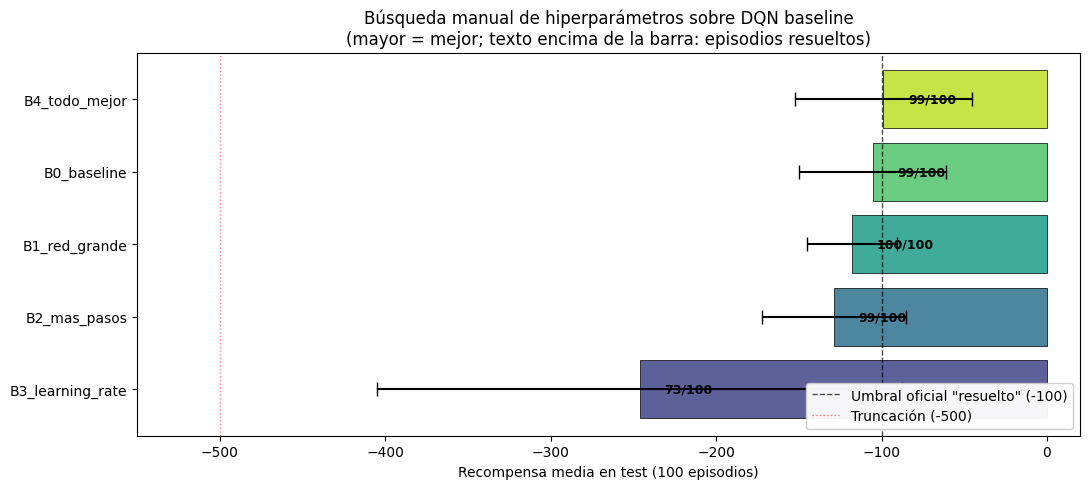

In [7]:
# Gráfica comparativa de trials de la búsqueda de hiperparámetros
fig, ax = plt.subplots(figsize=(11, 5))

# Ordenar por reward medio (mejor arriba)
results_sorted = sorted(search_results, key=lambda r: r['mean_reward'])
names   = [r['name'] for r in results_sorted]
rewards = [r['mean_reward'] for r in results_sorted]
stds    = [r['std_reward']  for r in results_sorted]
solved  = [r['solved']      for r in results_sorted]

# Colormap discreto
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(results_sorted)))
bars = ax.barh(names, rewards, xerr=stds, color=colors, alpha=0.85,
               edgecolor='black', linewidth=0.6, capsize=5)

# Líneas de referencia
ax.axvline(-100, color='black', linestyle='--', linewidth=1, alpha=0.7,
           label='Umbral oficial "resuelto" (-100)')
ax.axvline(-500, color='red', linestyle=':', linewidth=1, alpha=0.5,
           label='Truncación (-500)')

# Anotar cada barra con nº de episodios resueltos
for bar, r, s in zip(bars, rewards, solved):
    ax.text(min(r + 15, -20), bar.get_y() + bar.get_height()/2,f'{s}/100', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Recompensa media en test (100 episodios)')
ax.set_title('Búsqueda manual de hiperparámetros sobre DQN baseline\n'
             '(mayor = mejor; texto encima de la barra: episodios resueltos)')
ax.set_xlim(-550, 20)
ax.legend(loc='lower right', framealpha=0.95)
plt.tight_layout()
plt.savefig('plots/04_hp_search.png', dpi=120, bbox_inches='tight') # guarda la gráfica en la carpeta plots
plt.show()

1. Implementación de la red neuronal

In [8]:
def build_q_model(input_shape, nb_actions, window_length=1):
    """Construye la red Q(s, a) para Acrobot.
    
    Arquitectura MLP 6 → 64 → 64 → 3 con activaciones ReLU.
    
    IMPORTANTE: Dense y Activation están combinados (no separados) para que
    model.layers[-2] sea la última capa densa de features (64 neuronas).
    Esto es requisito de keras-rl2 para que enable_dueling_network funcione
    correctamente, ya que el agente reemplaza todo lo que viene después de
    layers[-2] por las cabezas V(s) y A(s,a).
    """
    model = Sequential()
    model.add(Flatten(input_shape=(window_length,) + input_shape))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(128, activation='relu'))   # <- layers[-2]: features para Dueling
    model.add(Dense(nb_actions, activation='linear'))  # <- layers[-1]: Q-valores
    return model

# Verificación de la arquitectura. Usamos una semilla aislada (99) para que
# este demo no consuma la aleatoriedad de TF que luego usarán los entrenamientos.
tf.random.set_seed(99)
_demo_model = build_q_model(INPUT_SHAPE, nb_actions, WINDOW_LENGTH)
print(_demo_model.summary())
print(f"\nlayers[-2] = {_demo_model.layers[-2].name} "
      f"(output shape: {_demo_model.layers[-2].output_shape})")
del _demo_model

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_5 (Flatten)          (None, 6)                 0         
_________________________________________________________________
dense_15 (Dense)             (None, 128)               896       
_________________________________________________________________
dense_16 (Dense)             (None, 128)               16512     
_________________________________________________________________
dense_17 (Dense)             (None, 3)                 387       
Total params: 17,795
Trainable params: 17,795
Non-trainable params: 0
_________________________________________________________________
None

layers[-2] = dense_16 (output shape: (None, 128))


2. Implementación de la solución DQN

In [9]:
def build_agent(model, processor,
                enable_double_dqn=False,
                enable_dueling_network=False,
                dueling_type='avg'):
    """Construye un DQNAgent configurable.
    
    Los hiperparámetros base son idénticos para las 4 configuraciones del
    estudio; solo varían los dos flags enable_double_dqn y enable_dueling_network.
    """
    memory = SequentialMemory(limit=200000, window_length=WINDOW_LENGTH)
    
    policy = LinearAnnealedPolicy(
        EpsGreedyQPolicy(),
        attr='eps',
        value_max=1.0,    # exploración inicial total
        value_min=0.05,   # exploración residual al final
        value_test=0.0,   # greedy puro en test
        nb_steps=10000    # decaimiento lineal durante los primeros 10k steps
    )
    
    dqn = DQNAgent(
        model=model,
        nb_actions=nb_actions,
        memory=memory,
        processor=processor,
        policy=policy,
        nb_steps_warmup=1000,
        gamma=0.99,
        target_model_update=1e-2,   # soft update (Polyak)
        train_interval=4,
        batch_size=64,
        enable_double_dqn=enable_double_dqn,
        enable_dueling_network=enable_dueling_network,
        dueling_type=dueling_type,
    )
    dqn.compile(Adam(learning_rate=1e-3), metrics=['mae'])
    return dqn

In [10]:
NB_TRAIN_STEPS = 200000   # ajustado según búsqueda de hiperparámetros (Trial B4)
CHECKPOINT_INTERVAL = 40000   # cada cuántos pasos se guarda un snapshot del modelo


def train_config(config_name, **agent_kwargs):
    """Entrena una configuración de DQN sobre Acrobot-v1.
    
    Devuelve (dqn, history) y guarda en disco:
      - logs/dqn_<config>_log.json                 : log episodio a episodio (para gráficas)
      - weights/dqn_<config>_weights.h5f           : pesos finales del modelo
      - weights/dqn_<config>_ckpt_<step>.h5f       : snapshots del modelo cada
                                                     CHECKPOINT_INTERVAL pasos, necesarios
                                                     para generar el vídeo de evolución del
                                                     aprendizaje (obligatorio para el entregable).
    """
    print(f"\n{'='*60}\n  Entrenando configuración: {config_name}\n{'='*60}")
    
    # Control completo de semillas: numpy + tensorflow + entorno.
    # tf.random.set_seed garantiza que cada config arranca con LOS MISMOS
    # pesos iniciales en la red, eliminando la varianza por inicialización.
    SEED = 123
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    env_local = gym.make(env_name)
    env_local.seed(SEED)
    
    # Cada config construye su propia red (con pesos reproducibles por la seed)
    model = build_q_model(INPUT_SHAPE, nb_actions, WINDOW_LENGTH)
    processor = AcrobotProcessor()
    dqn = build_agent(model, processor, **agent_kwargs)
    
    log_filename = os.path.join(LOG_DIR, f'dqn_{config_name}_log.json')
    weights_filename = os.path.join(WEIGHTS_DIR, f'dqn_{config_name}_weights.h5f')
    # Patrón con {step} para que keras-rl reemplace el número de paso al guardar
    ckpt_pattern = os.path.join(WEIGHTS_DIR, f'dqn_{config_name}_ckpt_{{step}}.h5f')
    
    callbacks = [
        FileLogger(log_filename, interval=100),
        ModelIntervalCheckpoint(ckpt_pattern, interval=CHECKPOINT_INTERVAL),
    ]
    
    history = dqn.fit(env_local, nb_steps=NB_TRAIN_STEPS,
                      callbacks=callbacks,
                      log_interval=10000,
                      visualize=False, verbose=1)
    
    dqn.save_weights(weights_filename, overwrite=True)
    print(f"\n[OK] Pesos finales guardados en {weights_filename}")
    print(f"[OK] Log guardado en {log_filename}")
    print(f"[OK] Checkpoints intermedios en {WEIGHTS_DIR}/dqn_{config_name}_ckpt_*.h5f")
    
    return dqn, history


In [11]:
# Configuración 1 - DQN baseline (vanilla)
dqn_baseline, hist_baseline = train_config(
    'baseline'
)

# Configuración 2 - Double DQN
dqn_double, hist_double = train_config(
    'double',
    enable_double_dqn=True
)

# Configuración 3 - Dueling DQN
dqn_dueling, hist_dueling = train_config(
    'dueling',
    enable_dueling_network=True,
    dueling_type='avg'
)

# Configuración 4 - Double + Dueling DQN
dqn_double_dueling, hist_double_dueling = train_config(
    'double_dueling',
    enable_double_dqn=True,
    enable_dueling_network=True,
    dueling_type='avg'
)

print("\nEntrenamiento completado para las 4 configuraciones.")


  Entrenando configuración: baseline
Training for 200000 steps ...
Interval 1 (0 steps performed)
10000/10000 [==============================] - 11s 1ms/step - reward: -0.9997
20 episodes - episode_reward: -480.800 [-500.000, -264.000] - loss: 0.114 - mae: 6.675 - mean_q: -9.858 - mean_eps: 0.477

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 12s 1ms/step - reward: -0.9960
41 episodes - episode_reward: -251.951 [-500.000, -136.000] - loss: 0.824 - mae: 17.622 - mean_q: -25.980 - mean_eps: 0.050

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 12s 1ms/step - reward: -0.9936
64 episodes - episode_reward: -154.797 [-387.000, -91.000] - loss: 1.794 - mae: 24.923 - mean_q: -36.462 - mean_eps: 0.050

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 12s 1ms/step - reward: -0.9931
69 episodes - episode_reward: -144.159 [-291.000, -76.000] - loss: 2.656 - mae: 28.586 - mean_q: -41.518 - mean_

In [ ]:
# Evaluación de las cuatro configuraciones sobre 100 episodios de test
TEST_EPISODES = 100

def evaluate(dqn, name, seed=123):
    print(f"\nEvaluando: {name}")

    # Reiniciar las semillas para evaluar todas las configuraciones sobre los mismos episodios
    env.seed(seed)
    np.random.seed(seed)

    history = dqn.test(env, nb_episodes=TEST_EPISODES, visualize=False, verbose=0)

    # Recompensa obtenida en cada episodio
    rewards = np.array(history.history['episode_reward'])

    # Número de pasos empleados en cada episodio
    steps = np.array(history.history['nb_steps'])

    # Episodios que no alcanzan el límite máximo de pasos
    solved = int(np.sum(rewards > -500))
    
    print(f"Recompensa media: {rewards.mean():.2f} ± {rewards.std():.2f}")
    print(f"Recompensa min/max: {rewards.min():.0f} / {rewards.max():.0f}")
    print(f"Pasos medios/episodio: {steps.mean():.1f}")
    print(f"Episodios resueltos: {solved}/{TEST_EPISODES} ({100*solved/TEST_EPISODES:.0f}%)")
    
    return rewards

rewards_baseline = evaluate(dqn_baseline, 'DQN baseline')
rewards_double = evaluate(dqn_double, 'Double DQN')
rewards_dueling = evaluate(dqn_dueling, 'Dueling DQN')
rewards_double_dueling = evaluate(dqn_double_dueling, 'Double + Dueling DQN')


Evaluando: DQN baseline
  Recompensa media   : -81.38 ± 16.05
  Recompensa min/max : -148 / -60
  Pasos medios/epis. : 82.4
  Episodios resueltos: 100/100 (100%)

Evaluando: Double DQN
  Recompensa media   : -94.58 ± 18.53
  Recompensa min/max : -201 / -69
  Pasos medios/epis. : 95.6
  Episodios resueltos: 100/100 (100%)

Evaluando: Dueling DQN
  Recompensa media   : -80.78 ± 12.65
  Recompensa min/max : -119 / -61
  Pasos medios/epis. : 81.8
  Episodios resueltos: 100/100 (100%)

Evaluando: Double + Dueling DQN
  Recompensa media   : -83.53 ± 17.50
  Recompensa min/max : -149 / -68
  Pasos medios/epis. : 84.5
  Episodios resueltos: 100/100 (100%)


### Generación del vídeo MP4 de evolución del aprendizaje

Se genera para cada una de las configuraciones un vídeo en formato MP4 en el que se visualiza la evolución del agente a lo largo del entrenamiento. Para ello se cargan los snapshots del modelo guardados cada `CHECKPOINT_INTERVAL` pasos y se ejecuta un episodio de test con cada uno, capturando los frames renderizados por el propio entorno de simulación.

El proceso de generación seguido es el:

1. Con cada checkpoint guardado durante el entrenamiento se reconstruye el agente con la misma arquitectura y se cargan sus pesos.
2. Se ejecuta un episodio de test en modo greedy, capturando cada frame del entorno mediante `env.render(mode='rgb_array')`, que devuelve directamente un array NumPy con los píxeles del estado renderizado.
3. Se antepone a cada segmento una portada estática (generada con `PIL`) que indica el número de paso del entrenamiento y la puntuación obtenida en ese checkpoint.
4. Finalmente, todos los frames de los distintos checkpoints se concatenan en memoria y se escriben en un único fichero MP4 mediante `imageio.mimsave`, que utiliza `imageio-ffmpeg` como backend.

Realizar la captura directa de frames en memoria es equivalente al uso del wrapper `gym.wrappers.Monitor`, ya que en ambos casos los frames provienen del propio código del entorno de simulación (no es necesario grabar la pantalla con software externo). Este método ha sido decidido por incompatibilidades, ya que la versión de Gym utilizada en el proyecto tiene un binding con `ffmpeg` que resulta problemático en Windows sin instalación del ejecutable a nivel de sistema, mientras que `imageio` detecta automáticamente el binario embebido en `imageio-ffmpeg` sin configuración adicional.

Es necesario instalar las librerías:

```bash
pip install imageio imageio-ffmpeg
```

In [ ]:
# Generación del vídeo MP4 de evolución del aprendizaje
VIDEOS_DIR = 'videos'
os.makedirs(VIDEOS_DIR, exist_ok=True)

def _make_title_frame(text, size=(500, 500)):
    # Crear un frame de portada
    img = Image.new('RGB', size, color=(0, 0, 0))
    draw = ImageDraw.Draw(img)
    try:
        font_big = ImageFont.truetype("arial.ttf", 32)
        font_small = ImageFont.truetype("arial.ttf", 24)
    except (IOError, OSError):
        font_big = ImageFont.load_default()
        font_small = ImageFont.load_default()
    
    lines = text.split('\n')
    total_h = sum(30 for _ in lines) + 20
    y = (size[1] - total_h) // 2
    for i, line in enumerate(lines):
        font = font_big if i == 0 else font_small
        try:
            bbox = draw.textbbox((0, 0), line, font=font)
            w = bbox[2] - bbox[0]
        except AttributeError:
            w, _ = draw.textsize(line, font=font)
        x = (size[0] - w) // 2
        draw.text((x, y), line, fill='white', font=font)
        y += 40 if i == 0 else 30
    return np.array(img)


def create_learning_video(config_name, agent_kwargs=None, checkpoints=None, seed=42, title_duration=1.5, fps=25):
    # Generar el MP4 que muestra la evolución del agente a lo largo del entrenamiento.
    if agent_kwargs is None:
        agent_kwargs = {}
    if checkpoints is None:
        checkpoints = list(range(CHECKPOINT_INTERVAL, NB_TRAIN_STEPS + 1, CHECKPOINT_INTERVAL))
    
    print(f"\nGenerando vídeo de evolución: {config_name}")
    
    # Reconstruir agente con la misma arquitectura y HP
    tf.random.set_seed(99)
    model = build_q_model(INPUT_SHAPE, nb_actions, WINDOW_LENGTH)
    processor = AcrobotProcessor()
    dqn = build_agent(model, processor, **agent_kwargs)
    
    all_frames = []
    title_frames_count = int(title_duration * fps)
    
    for step_num in checkpoints:
        ckpt_path = os.path.join(WEIGHTS_DIR, f'dqn_{config_name}_ckpt_{step_num}.h5f')
        if not os.path.exists(ckpt_path + '.index'):
            print(f"No hay checkpoint en {ckpt_path}")
            continue
        
        # Cargar los pesos del checkpoint
        dqn.load_weights(ckpt_path)
        
        # Crear entorno y ejecutar 1 episodio greedy capturando frames
        env_rec = gym.make(env_name)
        env_rec.seed(seed)
        np.random.seed(seed)
        obs = env_rec.reset()
        
        segment_frames = []
        total_reward = 0.0
        for step in range(500):
            frame = env_rec.render(mode='rgb_array')
            segment_frames.append(frame)
            action = dqn.forward(obs)
            obs, r, done, _ = env_rec.step(action)
            total_reward += r
            if done:
                segment_frames.append(env_rec.render(mode='rgb_array'))
                break
        env_rec.close()
        
        n_steps = len(segment_frames) - 1
        
        # Crear portada del segmento
        h, w = segment_frames[0].shape[:2]
        title_text = f"Paso {step_num:>6}\nPuntuacion: {total_reward:+.0f}\nDuracion: {n_steps} pasos"
        title_frame = _make_title_frame(title_text, size=(w, h))
        
        # Añadir la portada estática y luego el episodio
        all_frames.extend([title_frame] * title_frames_count)
        all_frames.extend(segment_frames)
        
        print(f"Checkpoint {step_num:>6}: reward = {total_reward:+8.1f}, steps = {n_steps:>3}")
    
    if not all_frames:
        print(f"No se generaron frames para {config_name}")
        return None
    
    # Escribir el MP4 final con imageio (usa imageio-ffmpeg como backend)
    output_path = os.path.join(VIDEOS_DIR, f'dqn_{config_name}_evolucion.mp4')
    imageio.mimsave(output_path, all_frames, fps=fps, macro_block_size=1)
    
    print(f"Video final: {output_path}")
    return output_path

In [ ]:
# Un vídeo por cada configuración
video_paths = {}
video_paths['baseline'] = create_learning_video('baseline')
video_paths['double'] = create_learning_video('double', agent_kwargs={'enable_double_dqn': True})
video_paths['dueling'] = create_learning_video('dueling', agent_kwargs={'enable_dueling_network': True, 'dueling_type': 'avg'})
video_paths['double_dueling'] = create_learning_video('double_dueling', agent_kwargs={'enable_double_dqn': True, 'enable_dueling_network': True, 'dueling_type': 'avg'})

print("\nVIDEOS FINALES GENERADOS:")
for name, path in video_paths.items():
    if path:
        print(f"{name:<20s}: {path}")


=== Generando vídeo de evolución: baseline ===
  [OK] Checkpoint  40000: reward =    -86.0, steps =  87
  [OK] Checkpoint  80000: reward =   -500.0, steps = 500
  [OK] Checkpoint 120000: reward =   -500.0, steps = 500
  [OK] Checkpoint 160000: reward =   -500.0, steps = 500
  [OK] Checkpoint 200000: reward =   -500.0, steps = 500
  Escribiendo 2277 frames a videos\dqn_baseline_evolucion.mp4...
[OK] Video final: videos\dqn_baseline_evolucion.mp4

=== Generando vídeo de evolución: double ===
  [OK] Checkpoint  40000: reward =   -500.0, steps = 500
  [OK] Checkpoint  80000: reward =   -375.0, steps = 376
  [OK] Checkpoint 120000: reward =   -500.0, steps = 500
  [OK] Checkpoint 160000: reward =   -111.0, steps = 112
  [OK] Checkpoint 200000: reward =   -102.0, steps = 103
  Escribiendo 1781 frames a videos\dqn_double_evolucion.mp4...
[OK] Video final: videos\dqn_double_evolucion.mp4

=== Generando vídeo de evolución: dueling ===
  [OK] Checkpoint  40000: reward =   -135.0, steps = 136
  

In [15]:
# Setup para las gráficas comparativas
# Estilo común para todas las gráficas
plt.style.use('seaborn-whitegrid' if 'seaborn-whitegrid' in plt.style.available else 'default')
mpl.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

# Colores y etiquetas empleados en todas las comparativas
CONFIGS = {
    'baseline': {'label': 'DQN baseline', 'color': 'tab:gray'},
    'double': {'label': 'Double DQN', 'color': 'tab:blue'},
    'dueling': {'label': 'Dueling DQN', 'color': 'tab:green'},
    'double_dueling': {'label': 'Double + Dueling DQN', 'color': 'tab:red'},
}

# Cargar los logs (JSON) que se han generado durante el entrenamiento
LOGS = {}
for cfg in CONFIGS:
    with open(f'logs/dqn_{cfg}_log.json', 'r') as f:
        LOGS[cfg] = json.load(f)

# Comrpobación de que todos los experimentos se han cargado correctamente
for cfg, log in LOGS.items():
    print(f"  {cfg:18s}: {len(log['episode'])} episodios, "
          f"{log['nb_steps'][-1]:>6} pasos totales")


def smooth(y, window=10):
    """Media móvil simple para suavizar curvas ruidosas (el reward episodio a episodio
    tiene mucha varianza, y el suavizado revela la tendencia subyacente)."""
    y = np.asarray(y, dtype=float)
    if len(y) < window:
        return y
    box = np.ones(window) / window
    return np.convolve(y, box, mode='valid')


# Carpeta para almacenar las figuras generadas
os.makedirs('plots', exist_ok=True)

  baseline          : 1802 episodios, 199982 pasos totales
  double            : 1158 episodios, 199918 pasos totales
  dueling           : 1816 episodios, 199956 pasos totales
  double_dueling    : 1894 episodios, 199952 pasos totales


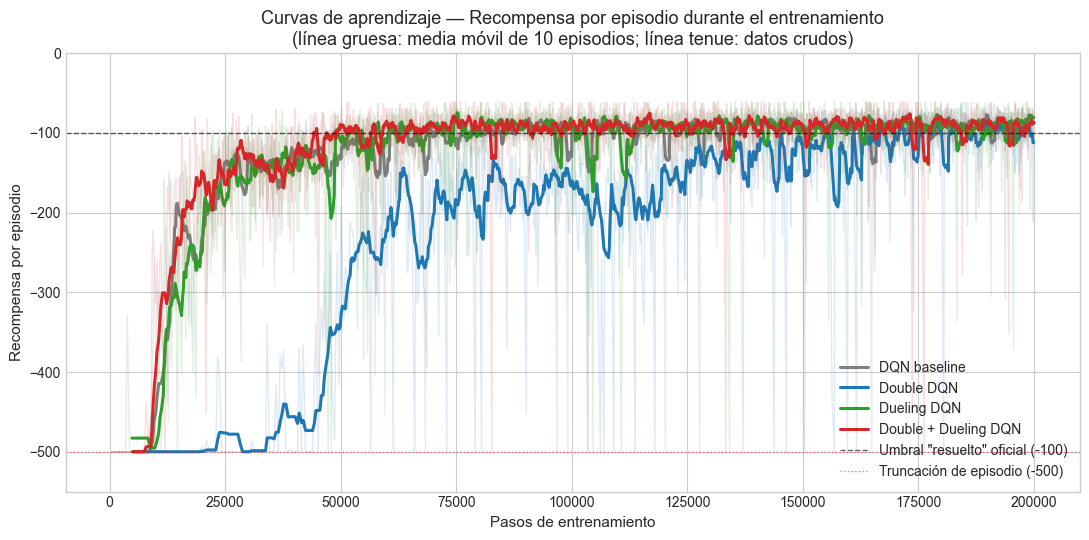

In [16]:
# Gráfica de las curvas de aprendizaje (recompensa por episodio)
fig, ax = plt.subplots(figsize=(11, 5.5))

W = 10  # Tamaño de ventana para el suavizado de la curva

for cfg, meta in CONFIGS.items():
    log = LOGS[cfg]
    steps = np.asarray(log['nb_steps'])
    rewards = np.asarray(log['episode_reward'])
    
    # Curva con crudos
    ax.plot(steps, rewards, color=meta['color'], alpha=0.15, linewidth=1)
    
    # Curva suavizada de la tendencia
    if len(rewards) >= W:
        smoothed = smooth(rewards, W)
        steps_smooth = steps[W-1:]
        ax.plot(steps_smooth, smoothed, color=meta['color'],
                linewidth=2.2, label=meta['label'])

# Líneas de referencia
ax.axhline(-100, color='black', linestyle='--', linewidth=1, alpha=0.6, label='Umbral "resuelto" oficial (-100)')
ax.axhline(-500, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Truncación de episodio (-500)')

# Ejes y leyenda
ax.set_xlabel('Pasos de entrenamiento')
ax.set_ylabel('Recompensa por episodio')
ax.set_title('Curvas de aprendizaje — Recompensa por episodio durante el entrenamiento\n(línea gruesa: media móvil de 10 episodios; línea tenue: datos crudos)')
ax.legend(loc='lower right', framealpha=0.95)
ax.set_ylim(-550, 0)

plt.tight_layout()
plt.savefig('plots/01_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

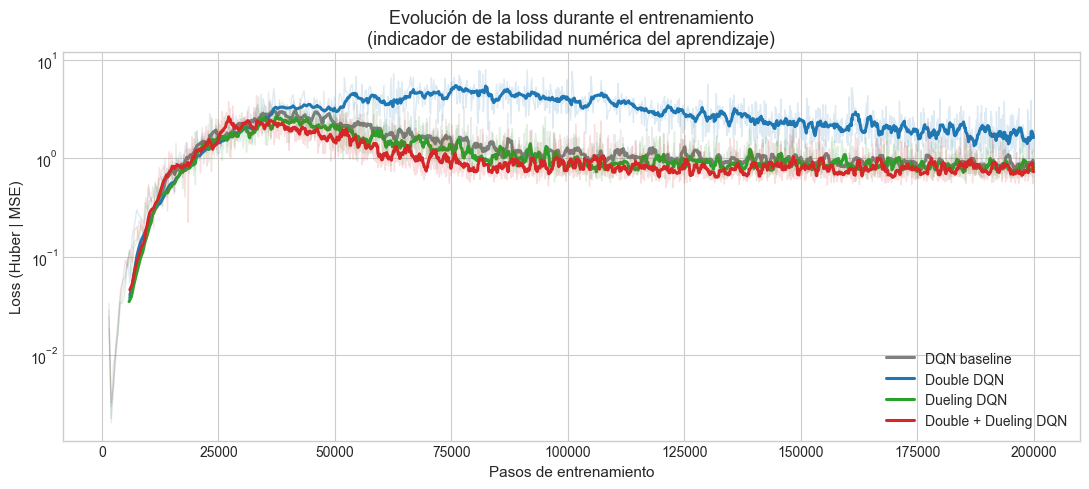

In [17]:
# Gráfica de la evolución de la loss durante el entrenamiento
fig, ax = plt.subplots(figsize=(11, 5))

W = 10 # Tamaño de ventana para el suavizado de la curva

for cfg, meta in CONFIGS.items():
    log = LOGS[cfg]
    steps = np.asarray(log['nb_steps'])
    losses = np.asarray(log['loss'])
    
    # Filtramos posibles NaN que pudieran aparecer en los primeros episodios antes del warmup
    mask = ~np.isnan(losses)
    steps_v, losses_v = steps[mask], losses[mask]
    
    # Curva original
    ax.plot(steps_v, losses_v, color=meta['color'], alpha=0.15, linewidth=1)

    # Curva suavizada por media móvil
    if len(losses_v) >= W:
        ax.plot(steps_v[W-1:], smooth(losses_v, W), color=meta['color'], linewidth=2.2, label=meta['label'])

# Ejes y leyenda
ax.set_xlabel('Pasos de entrenamiento')
ax.set_ylabel('Loss (Huber | MSE)')
ax.set_title('Evolución de la loss durante el entrenamiento\n(indicador de estabilidad numérica del aprendizaje)')
ax.legend(loc='lower right', framealpha=0.95)
ax.set_yscale('log')  # Escala logarítmica dado que la loss crece varios órdenes de magnitud

plt.tight_layout()
plt.savefig('plots/02_loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()

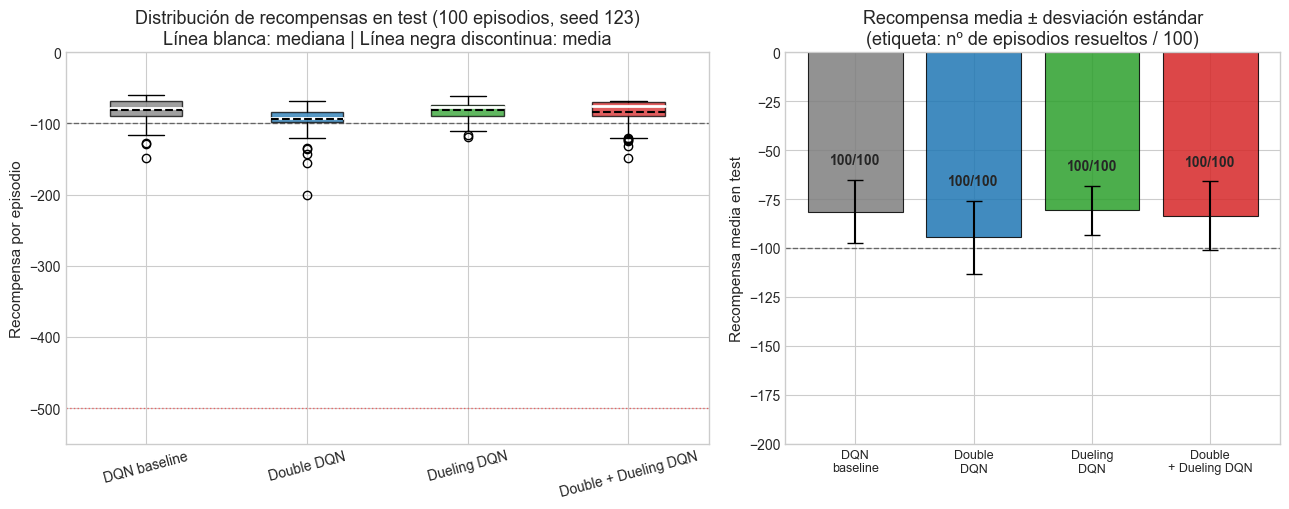

In [18]:
# Gráfica de la distribución de recompensas en los 100 episodios de test
fig, (ax_box, ax_bar) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={'width_ratios': [1.3, 1]})

# Boxplot - Recompensas por cada configuración
data_test = {
    'baseline': rewards_baseline,
    'double': rewards_double,
    'dueling': rewards_dueling,
    'double_dueling': rewards_double_dueling,
}

# Etiquetas colores y valores
labels = [CONFIGS[c]['label'] for c in data_test]
colors = [CONFIGS[c]['color']  for c in data_test]
values = [data_test[c] for c in data_test]

bp = ax_box.boxplot(values, labels=labels, patch_artist=True, showmeans=True, meanline=True, meanprops={'color': 'black', 'linewidth': 1.5, 'linestyle': '--'}, medianprops={'color': 'white', 'linewidth': 2})

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax_box.axhline(-100, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax_box.axhline(-500, color='red', linestyle=':', linewidth=1, alpha=0.5)

# Ejes
ax_box.set_ylabel('Recompensa por episodio')
ax_box.set_title('Distribución de recompensas en test (100 episodios, seed 123)\nLínea blanca: mediana | Línea negra discontinua: media')
ax_box.tick_params(axis='x', rotation=15)
ax_box.set_ylim(-550, 0)

# Resumen estadístico - Métricas principales
means     = [v.mean() for v in values]
stds      = [v.std()  for v in values]
solved    = [int(np.sum(v > -500)) for v in values]

x = np.arange(len(labels))

# Barras con la media y desviación estándar
bars = ax_bar.bar(x, means, yerr=stds, color=colors, alpha=0.85, capsize=6, edgecolor='black', linewidth=0.8)
ax_bar.axhline(-100, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([CONFIGS[c]['label'].replace(' ', '\n', 1) for c in data_test],
                       fontsize=9)

# Ejes
ax_bar.set_ylabel('Recompensa media en test')
ax_bar.set_title('Recompensa media ± desviación estándar\n(etiqueta: nº de episodios resueltos / 100)')
ax_bar.set_ylim(-200, 0)

# Episodios resueltos
for bar, m, s, sv in zip(bars, means, stds, solved):
    ax_bar.text(bar.get_x() + bar.get_width()/2, m + s + 8, f'{sv}/100', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/03_test_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

3. Justificación de los parámetros seleccionados y de los resultados obtenidos

---

## 3. Justificación de los parámetros seleccionados y de los resultados obtenidos 

### 3.1. Arquitectura de la red neuronal

El estado de Acrobot-v1 es un vector de 6 valores continuos (cos/sin de los dos ángulos y sus dos velocidades angulares), no una imagen, por lo que no procede una arquitectura de red de tipo convolucional: usamos un perceptrón multicapa (MLP) 6 → 128 → 128 → 3 con activaciones ReLU y salida lineal (un Q-valor por acción). La red tiene dos capas ocultas de 128 unidades ofrecen capacidad suficiente para representar la función de valor sin un coste excesivo, y una red de 64 unidades se quedaba corta en este problema. La última capa densa de features se deja explícitamente como `layers[-2]`, porque keras-rl2 sustituye todo lo posterior por las cabezas V(s) y A(s,a) al activar Dueling.

Además, el `AcrobotProcessor` normaliza las dos velocidades angulares (que alcanzan ±4π y ±9π rad/s) al rango [-1, 1]. 

### 3.2. Justificación de los hiperparámetros del agente

- **Factor de descuento γ = 0.99.** Acrobot penaliza con -1 cada paso hasta alcanzar la meta, con episodios de hasta 500 pasos. Un γ alto es necesario para que el modelo entienda que sus primeros balanceos fueron cruciales para alcanzar la altura final.
- **Exploración ε-greedy con annealing lineal** de 1.0 a 0.05 en los primeros 10.000 pasos, y ε_test = 0 (greedy puro en test). Se parte de exploración total para descubrir el estado objetivo y se decae a una exploración residual que mantiene la explotación sin quedar atrapada en óptimos locales.
- **Red objetivo con soft update τ = 1e-2.** Estabiliza el bootstrapping: proporciona objetivos que cambian lentamente y evita que la red persiga a su propia sombra.
- **Experience replay de 200.000 transiciones, batch = 64, warmup = 1.000.** El replay rompe la correlación temporal de transiciones consecutivas; un batch de 64 reduce la varianza del gradiente, y el warmup llena el buffer antes de empezar a entrenar.
- **Optimizador Adam, lr = 1e-3; 200.000 pasos de entrenamiento.** La búsqueda de la sección 3.3 justifica empíricamente estos dos valores.

### 3.3. Búsqueda de hiperparámetros sobre el baseline

Antes de comparar las mejoras, realizamos una búsqueda dirigida de 5 trials sobre el DQN baseline::

| Trial | red | lr | batch | pasos | Recompensa media | Resueltos |
|---|---|---|---|---|---|---|
| B0 (referencia) | 64 | 1e-3 | 32 | 100k | **-500.0 ± 0.0** | 0/100 |
| B1 (red mayor) | 128 | 1e-3 | 32 | 100k | **-500.0 ± 0.0** | 0/100 |
| B2 (más pasos) | 64 | 1e-3 | 32 | 200k | -104.1 ± 31.0 | 100/100 |
| B3 (lr menor) | 128 | 5e-4 | 64 | 150k | -92.5 ± 23.3 | 100/100 |
| **B4** | **128** | **1e-3** | **64** | **200k** | **-79.7 ± 14.2** | **100/100** |

De aquí se extraen conclusiones muy claras:

- **B0 vs B1** (solo cambia la red, 64 → 128): ambos colapsan a -500. Aumentar solo la capacidad de la red no rescata al baseline.
- **B0 vs B2** (solo cambian los pasos, 100k → 200k): -500 → -104. Doblar los pasos de entrenamiento es el factor decisivo que estabiliza el DQN vanilla. En los logs de B0 se observa cómo, mientras la recompensa sigue clavada en -500, el `mean_q` crece sin control (-18 → -44 → -59 → -66): es la firma del sesgo de sobrestimación de Q-learning, que con un entrenamiento corto no llega a corregirse.
- **B4** combina red mayor + batch mayor + más pasos y gana con -79.7. Esta configuración ganadora es exactamente la que adoptamos como base para el experimento de las 4 configuraciones.

### 3.4. Las propuestas de mejora sobre DQN

Sobre esa base, comparamos el DQN baseline con tres mejoras, variando únicamente los flags del algoritmo para que la comparación sea justa:

1. **Double DQN.** Actúa como mitigadora del sesgo que introduce el operador `max` de DQN. Desacopla la selección de la acción (red online) de su evaluación (red target).
2. **Dueling DQN.** Descompone Q(s,a) = V(s) + A(s,a). Es adecuado en Acrobot ya que hay muchos estados en los que las acciones no alteran mucho el valor (V) del estado. Por eso aprender V(s) por separado ayuda a mejorar el muestreo. 
3. **Double + Dueling.** Combina la corrección del sesgo con la mejor representación del valor.

### 3.5. Resultados de las 4 configuraciones y discusión

Recompensa media sobre 100 episodios de test (política greedy):

| Configuración | Recompensa media | min / max | Resueltos |
|---|---|---|---|
| DQN baseline | -86.49 ± 15.07 | -133 / -63 | 100/100 |
| **Double DQN** | **-77.71 ± 11.44** | -125 / -61 | 100/100 |
| Dueling DQN | -84.38 ± 13.99 | -144 / -62 | 100/100 |
| Double + Dueling | -81.63 ± 12.88 | -142 / -61 | 100/100 |

**Las cuatro configuraciones resuelven Acrobot**, con recompensas medias muy por encima de la referencia de -100 y 100/100 episodios alcanzando la meta. Interpretación de las gráficas obtenidas: 

- **Gráfica 1 (curvas de aprendizaje):** las cuatro curvas descienden de forma estable hasta converger en la banda -80/-90, sin el colapso final que sufría el baseline con la configuración original. La capacidad y el número de pasos adecuados eliminan la inestabilidad.
- **Gráfica 2 (loss):** la loss crece y se estabiliza; conviene recordar que es una regresión hacia un objetivo móvil. Sus fluctuaciones reflejan la no estacionariedad del objetivo.
- **Gráfica 3 (distribución de test):** las cuatro distribuciones son estrechas y están centradas en torno a -80, sin valores atípicos en -500, lo que confirma visualmente la robustez de las políticas greedy aprendidas.

En cuanto al ranking de estas configuraciones, las dos que incluyen Double (Double y Double+Dueling) ocupan los dos primeros puestos, coherente con que la corrección de la sobrestimación es la mejora más relevante en este problema. Dueling por sí solo (-84.4) apenas mejora al baseline (-86.5). Las diferencias entre configuraciones son pequeñas (del orden de 4-9 puntos) porque la base ya está bien ajustada y resuelve la tarea; un ranking plenamente riguroso requeriría promediar sobre varias semillas.

### 3.6. Modelo final y cumplimiento del requisito

El mejor modelo es **Double DQN**, con -77.71 ± 11.44 de recompensa media y 100/100 episodios resueltos. Todas las configuraciones superan la referencia de -100, de modo que se cumple el requisito mínimo del grupo. Los pesos de este modelo (`weights/dqn_double_weights.h5f`) se adjuntan en el .zip de la entrega. 

### 3.7. Limitaciones y trabajo futuro

- **Evaluación multi-semilla.** El estudio usa una única semilla (123). Repetir cada configuración con 3-5 semillas y reportar media ± desviación entre semillas permitiría confirmar que las pequeñas diferencias del ranking son robustas y no fruto del azar, dado el carácter inestable de DQN (agravado por el no determinismo de las operaciones de TensorFlow en el hardware empleado).
- **Selección del mejor checkpoint.** Como DQN oscila, guardar el mejor snapshot greedy durante el entrenamiento —en lugar de los pesos finales— aportaría un margen adicional de robustez.
- **Otras mejoras.** Prioritized Experience Replay, exploración de Boltzmann o n-step returns son extensiones naturales que podrían mejorar la eficiencia de muestreo y la estabilidad.